In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
# Load the dataset
df = pd.read_csv('created_house_price_prediction.csv')
x=df.drop("Price",axis=1)
x=pd.get_dummies(x, drop_first=True)
y=df["Price"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)
r2_best=0

for i in range(1,6):
    poly=PolynomialFeatures(degree=i)
    x_train_poly=poly.fit_transform(x_train)
    x_test_poly=poly.transform(x_test)
    model=LinearRegression()
    model.fit(x_train_poly,y_train)
    y_pred=model.predict(x_test_poly)
    r2=r2_score(y_test,y_pred)
    if(r2_best<r2):
        r2_best=r2
        degree_best=i
print("Best Degree:", degree_best)
print("Best R2 Score:", r2_best)

ValueError: Input X contains NaN.
PolynomialFeatures does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

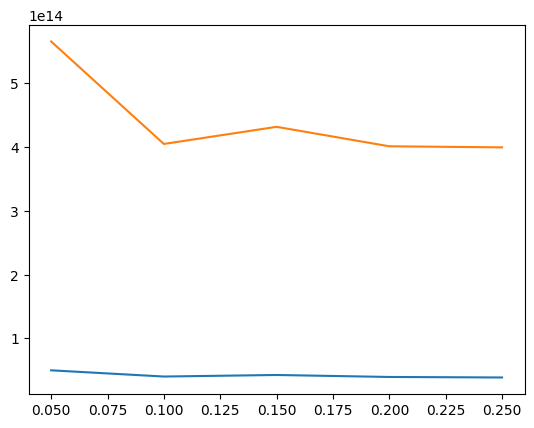

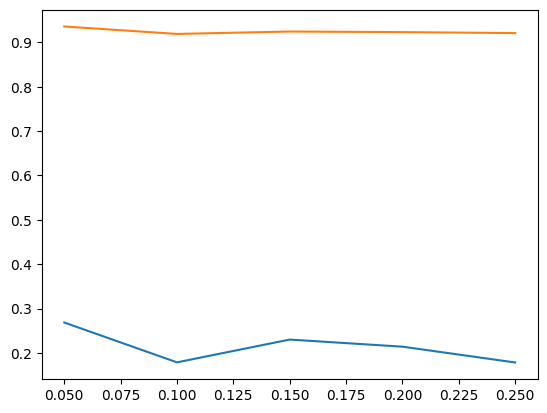

In [6]:
from matplotlib import pyplot as plt

df=pd.read_csv('created_house_price_prediction.csv')
df.dropna(inplace=True)
x=df.drop("Price",axis=1)
x=pd.get_dummies(x, drop_first=True)
y=df["Price"]
degree_best=5
test_sizes = [0.05, 0.10, 0.15, 0.20, 0.25]
poly_r2=[]
poly_mse=[]
r2=[]
mse=[]
for i in test_sizes:
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=i,random_state=42)
    poly=PolynomialFeatures(degree=degree_best)
    x_train_poly=poly.fit_transform(x_train)
    x_test_poly=poly.transform(x_test)
    model=LinearRegression()
    model.fit(x_train_poly,y_train)
    y_pred=model.predict(x_test_poly)
    poly_r2.append(r2_score(y_test,y_pred))
    poly_mse.append(mean_squared_error(y_test,y_pred))
    lr=LinearRegression()
    lr.fit(x_train,y_train)
    y_pred_lr=lr.predict(x_test)
    r2.append(r2_score(y_test,y_pred_lr))
    mse.append(mean_squared_error(y_test,y_pred_lr))
plt.plot(test_sizes,poly_mse)
plt.plot(test_sizes,mse)
plt.show()
plt.plot(test_sizes,r2)
plt.plot(test_sizes,poly_r2)
plt.show()
